[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/AI-og-helse/blob/main/uke03-dyplæring/02b_cnn_trening.ipynb)

# 🚀 02b: CNN Trening og Lagring

**Fra Natur til Medisin: Tren og Lagre CNN-modellen**

---

## 🎯 Mål for denne delen

I denne notebooken skal vi:
- **Laste inn** modell og data fra del 1
- **Trene** CNN-modellen med progress tracking
- **Visualisere** treningsresultater
- **Lagre** den trente modellen og historikk
- **Forberede** for testing i del 3

## Forutsetninger

Denne notebooken bygger på `02a_cnn_bildeklassifikasjon.ipynb`. Sørg for at du har:
- ✅ Fullført del 1
- ✅ Lagret modell og data
- ✅ Forstått CNN-arkitekturen

## Praktisk arbeidsguide: kjør notebooken steg for steg

Bruk denne guiden mens du jobber. Målet her er å gå fra ferdig oppsatt CNN-arkitektur til faktisk trening, tolkning av treningsforløp og lagring av beste modell for videre testing.

### Del 1: Miljø og enhet

1. **Nå kjør miljøoppsettet, importene og enhetsvalget.**
2. **Nå se etter dette:**
   - Ingen importfeil
   - PyTorch fungerer
   - Du ser hvilken enhet som brukes (`CPU`, `GPU` eller `MPS`)
3. **Ikke gå videre før:**
   - notebooken er klar til å kjøre trening stabilt

### Del 2: Last inn grunnlaget fra del 1

1. **Nå kjør cellene som laster inn data, transformasjoner, DataLoaders og modellarkitektur.**
2. **Nå se etter dette:**
   - At `flower_data_info.pkl` finnes
   - At train/val/test-data lastes riktig
   - At modellen opprettes og flyttes til riktig device
3. **Ikke gå videre før:**
   - hele oppsettet fra `02a` er klart til trening

### Del 3: Treningsfunksjoner

1. **Nå kjør funksjonene for trening og validering.**
2. **Nå se etter dette:**
   - Hvordan loss, accuracy, scheduler og early stopping brukes
   - Hvordan beste modell lagres underveis
3. **Ikke gå videre før:**
   - du skjønner hva som skjer i én trenings-epoke og én validerings-epoke

### Del 4: Start trening

1. **Nå kjør treningscellen.**
2. **Nå se etter dette:**
   - Om `train_loss` faller
   - Om `val_accuracy` forbedres
   - Om early stopping og læringsrate virker fornuftig
3. **Ikke gå videre før:**
   - treningen er fullført uten feil
   - du kan oppsummere treningsforløpet kort

### Del 5: Visualiser og tolk resultatene

1. **Nå kjør plottecellene og analysecellen.**
2. **Nå se etter dette:**
   - Gap mellom trening og validering
   - Tegn på overfitting, underfitting eller stagnasjon
   - Om modellen ser ut til å generalisere rimelig godt
3. **Ikke gå videre før:**
   - du har tolket både kurver og tekstlig analyse

### Del 6: Lagre modellen og gå videre

1. **Nå kjør lagringsdelen.**
2. **Nå se etter dette:**
   - Hvilken modell som regnes som best
   - Hvilke filer som brukes videre i neste notebook
3. **Ikke avslutt denne notebooken før:**
   - du kan forklare hva som er trent her, og hva som gjenstår i testdelen

---

### Kort arbeidsregel

- **Hvis en celle feiler: stopp der.**
- **Hvis modell eller data ikke lastes inn: gå tilbake til `02a`.**
- **Hvis kurvene ser rare ut: tolk dem før du går videre.**
- **Ikke gå videre bare fordi trening er ferdig; gå videre når du skjønner hva resultatene betyr.**

## 🔧 Miljøoppsett

Vi starter med å sette opp miljøet og laste inn nødvendige biblioteker.

### Mini-guide før miljøoppsett

**Nå gjør du dette:**
- Kjør miljøoppsettcellen.
- Kjør deretter importene og enhetsoppsettet.

**Nå se etter dette:**
- At nødvendige biblioteker lastes inn uten feil
- Om du kjører på `CPU`, `GPU` eller `MPS`
- At notebooken er klar til å trene modellen

**Ikke gå videre før:**
- første kodeceller kjører uten feil
- du vet hvilken enhet treningen faktisk skal kjøre på

In [1]:
import sys
import subprocess
import os

# Sjekk om vi kjører i Google Colab
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("🚀 Kjører i Google Colab")
    
    # Installer nødvendige pakker
    !pip install seaborn --quiet
    
    # Sjekk om mappen allerede eksisterer
    if not os.path.exists('AI-og-helse'):
        print(" Laster ned kursmateriell...")
        try:
            !git clone https://github.com/arvidl/AI-og-helse.git
            os.chdir('AI-og-helse')
        except:
            print("❌ Kunne ikke laste ned kursmateriell")
            print("Last ned manuelt fra: https://github.com/arvidl/AI-og-helse")
else:
    print("💻 Kjører lokalt eller i Codespaces")
    
print("✅ Miljøoppsett fullført!")

💻 Kjører lokalt eller i Codespaces
✅ Miljøoppsett fullført!


In [2]:
# Importer nødvendige biblioteker
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
from torchvision import datasets
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import seaborn as sns
from pathlib import Path
import random
from sklearn.model_selection import train_test_split
import pickle
import time
import warnings
warnings.filterwarnings('ignore')

SEED = 42

# Sett random seeds for reproduserbarhet
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def seed_worker(worker_id):
    """Sikrer deterministisk oppførsel også hvis workers skrus på senere."""
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)


def create_deterministic_dataloader(dataset, batch_size, shuffle=False, num_workers=0, seed=SEED):
    """Opprett DataLoader med deterministisk shuffle."""
    generator = torch.Generator()
    generator.manual_seed(seed)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        generator=generator if shuffle else None,
        worker_init_fn=seed_worker if num_workers > 0 else None,
    )


print("📚 Biblioteker importert med deterministisk oppsett!")

📚 Biblioteker importert!


## Reproduserbarhet

Denne notebooken bruker fast seed (`42`) og deterministiske datasplitt/DataLoaders der det er praktisk mulig. Ved ren kjøring fra toppen bør du derfor få svært like resultater mellom kjøringer, men små avvik kan fortsatt forekomme på tvers av `CPU`, `MPS` og `CUDA`, eller hvis enkeltceller kjøres om igjen ute av rekkefølge. Ved dataaugmentering er målet stabilitet mellom hele kjøringer, ikke nødvendigvis identiske resultater hvis du re-kjører enkeltceller midt i samme sesjon.

In [3]:
# Konfigurer enhet (CPU, GPU, eller MPS)
def setup_device():
    """Sett opp best tilgjengelig enhet"""
    if torch.cuda.is_available():
        device = torch.device('cuda')
        print(f"🚀 Bruker GPU: {torch.cuda.get_device_name(0)}")
        print(f"💾 GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        device = torch.device('mps')
        print("🍎 Bruker MPS (Apple Silicon)")
    else:
        device = torch.device('cpu')
        print("💻 Bruker CPU")
    
    return device

device = setup_device()
print(f"✅ Enhet satt til: {device}")

🍎 Bruker MPS (Apple Silicon)
✅ Enhet satt til: mps


## Last inn modell og data

Vi laster inn modellarkitekturen og dataene som ble lagret i del 1.

### Mini-guide før innlasting av modell og data

**Nå gjør du dette:**
- Kjør cellene som laster inn datasplitt, transformasjoner, dataset-klasse og modellarkitektur fra del 1.
- Bekreft at alt fra `02a` faktisk er tilgjengelig.

**Nå se etter dette:**
- At `flower_data_info.pkl` finnes
- At klassene og datasplittene lastes inn riktig
- At DataLoaders opprettes uten feil
- At modellen flyttes til riktig device

**Ikke gå videre før:**
- du vet at grunnlaget fra `02a` er lastet inn korrekt

In [4]:
# Last inn data-info fra del 1
try:
    with open('flower_data_info.pkl', 'rb') as f:
        data_info = pickle.load(f)
    
    # Pakk ut data
    X_train = data_info['X_train']
    y_train = data_info['y_train']
    X_val = data_info['X_val']
    y_val = data_info['y_val']
    X_test = data_info['X_test']
    y_test = data_info['y_test']
    class_names = data_info['class_names']
    class_mapping = data_info['class_mapping']
    num_classes = data_info['num_classes']
    
    print("✅ Data lastet inn fra del 1!")
    print(f"📊 Treningssett: {len(X_train)} bilder")
    print(f"📊 Valideringssett: {len(X_val)} bilder")
    print(f"📊 Testsett: {len(X_test)} bilder")
    print(f"📚 Klasser: {class_names}")
    
except FileNotFoundError:
    print("❌ Kunne ikke finne 'flower_data_info.pkl'")
    print("💡 Sørg for at du har fullført del 1 først!")
    print("📁 Kjør '02a_cnn_bildeklassifikasjon.ipynb' først")
    raise

✅ Data lastet inn fra del 1!
📊 Treningssett: 3021 bilder
📊 Valideringssett: 648 bilder
📊 Testsett: 648 bilder
📚 Klasser: ['Tusenfryd', 'Løvetann', 'Rose', 'Solsikke', 'Tulipan']


In [5]:
# Definer transformasjoner (samme som i del 1)
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

print("✅ Transformasjoner definert!")

✅ Transformasjoner definert!


In [6]:
# Custom Dataset klasse (samme som i del 1)
class FlowerDataset(Dataset):
    """Custom dataset for blomsterbilder"""
    
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        label = self.labels[idx]
        
        # Last bilde
        image = Image.open(image_path).convert('RGB')
        
        # Anvend transform
        if self.transform:
            image = self.transform(image)
            
        return image, label

# Opprett datasets og DataLoaders (num_workers=0 for enklest mulig reproduksjon)
train_dataset = FlowerDataset(X_train, y_train, train_transform)
val_dataset = FlowerDataset(X_val, y_val, val_transform)
test_dataset = FlowerDataset(X_test, y_test, val_transform)

# Opprett DataLoaders
batch_size = 32
train_loader = create_deterministic_dataloader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = create_deterministic_dataloader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader = create_deterministic_dataloader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)

print(f"✅ DataLoaders opprettet med batch_size={batch_size}")
print(f"  Treningsbatcher: {len(train_loader)}")
print(f"  Valideringsbatcher: {len(val_loader)}")
print(f"  Testbatcher: {len(test_loader)}")

✅ DataLoaders opprettet med batch_size=32
  Treningsbatcher: 95
  Valideringsbatcher: 21
  Testbatcher: 21


In [7]:
# Last inn modellarkitektur
class SimpleCNN(nn.Module):
    """Enkel CNN for blomsterklassifikasjon"""
    
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        
        # Konvolusjonslag
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        
        # Pooling
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dropout for regularisering
        self.dropout = nn.Dropout(0.5)
        
        # Fully connected lag
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.fc2 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        # Konvolusjonsblokk 1
        x = self.pool(torch.relu(self.conv1(x)))
        
        # Konvolusjonsblokk 2
        x = self.pool(torch.relu(self.conv2(x)))
        
        # Konvolusjonsblokk 3
        x = self.pool(torch.relu(self.conv3(x)))
        
        # Flatten for fully connected lag
        x = x.view(-1, 128 * 28 * 28)
        
        # Fully connected lag
        x = torch.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Opprett modell
model = SimpleCNN(num_classes=num_classes)
model = model.to(device)

print("✅ Modell opprettet og flyttet til enhet!")
print(f"🏗️ Modellarkitektur: {model.__class__.__name__}")
print(f"📊 Antall parametere: {sum(p.numel() for p in model.parameters()):,}")

✅ Modell opprettet og flyttet til enhet!
🏗️ Modellarkitektur: SimpleCNN
📊 Antall parametere: 51,476,549


### Mini-guide før treningsfunksjonene

**Nå gjør du dette:**
- Les kort gjennom funksjonene for trening og validering.
- Legg spesielt merke til loss-funksjon, optimizer, scheduler og early stopping.

**Nå se etter dette:**
- Hvordan én epoke trenes
- Hvordan validering skiller seg fra trening
- Hvordan beste modell lagres underveis

**Ikke gå videre før:**
- du skjønner forskjellen på `train_epoch`, `validate_epoch` og `train_model`

## 🚀 Treningsfunksjoner

Nå definerer vi funksjonene for trening og validering av modellen.

In [8]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Tren modellen i en epoke"""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(output.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

def validate_epoch(model, dataloader, criterion, device):
    """Valider modellen i en epoke"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in dataloader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            loss = criterion(output, target)
            
            running_loss += loss.item()
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    
    return epoch_loss, epoch_acc

print("✅ Treningsfunksjoner definert!")

✅ Treningsfunksjoner definert!


In [9]:
def train_model(model, train_loader, val_loader, num_epochs=20, learning_rate=0.001):
    """Tren modellen med progress tracking"""
    
    # Loss function og optimizer
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)
    
    # Lagre treningshistorikk
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    best_val_acc = 0.0
    patience_counter = 0
    
    print("🚀 Starter trening...")
    print("=" * 60)
    print(f"📊 Antall epoker: {num_epochs}")
    print(f"📊 Learning rate: {learning_rate}")
    print(f"📊 Batch size: {train_loader.batch_size}")
    print(f"📊 Enhet: {device}")
    print("=" * 60)
    
    start_time = time.time()
    
    for epoch in range(num_epochs):
        epoch_start = time.time()
        
        print(f"\nEpoke {epoch+1}/{num_epochs}")
        print("-" * 30)
        
        # Tren
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        
        # Valider
        val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
        
        # Oppdater learning rate
        scheduler.step(val_loss)
        
        # Lagre metrikker
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        train_accs.append(train_acc)
        val_accs.append(val_acc)
        
        # Beregn tid
        epoch_time = time.time() - epoch_start
        
        # Vis progress
        print(f"Trenings-Loss: {train_loss:.4f}, Trenings-Accuracy: {train_acc:.2f}%")
        print(f"Validerings-Loss: {val_loss:.4f}, Validerings-Accuracy: {val_acc:.2f}%")
        print(f"Learning Rate: {optimizer.param_groups[0]['lr']:.6f}")
        print(f"Epoke-tid: {epoch_time:.1f}s")
        
        # Early stopping
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            # Lagre beste modell
            torch.save(model.state_dict(), 'best_flower_model.pth')
            print(f"💾 Ny beste modell lagret! (Accuracy: {val_acc:.2f}%)")
        else:
            patience_counter += 1
            print(f"⏳ Ingen forbedring i {patience_counter} epoker")
        
        if patience_counter >= 5:
            print(f"\n⏹️ Early stopping ved epoke {epoch+1}")
            break
    
    total_time = time.time() - start_time
    
    print("\n✅ Trening fullført!")
    print(f"⏱️ Total tid: {total_time/60:.1f} minutter")
    print(f"📊 Beste validerings-accuracy: {best_val_acc:.2f}%")
    
    return {
        'train_losses': train_losses,
        'val_losses': val_losses, 
        'train_accs': train_accs,
        'val_accs': val_accs,
        'best_val_acc': best_val_acc,
        'total_time': total_time
    }

print("✅ Treningsfunksjon definert!")

✅ Treningsfunksjon definert!


### Mini-guide før start på trening

**Nå gjør du dette:**
- Kjør treningscellen.
- Følg med på output fra hver epoke i stedet for å hoppe rett til slutten.

**Nå se etter dette:**
- At `train_loss` synker
- At `val_accuracy` forbedres over tid
- Om beste modell lagres når valideringsytelsen øker
- Om early stopping slår inn på et rimelig tidspunkt

**Ikke gå videre før:**
- treningen er ferdig uten feil
- du kan oppsummere utviklingen i én kort setning

## 🚀 Start trening

Nå starter vi treningen av modellen. Dette kan ta noen minutter avhengig av enheten din (ca. 4 min på MacBook M4 Max med early stopping ved epoke 19)

In [10]:
%%time
# Kjør trening
print("🚀 Starter trening av modellen...")
print("⏳ Dette kan ta noen minutter avhengig av enheten din...")

history = train_model(model, train_loader, val_loader, num_epochs=25, learning_rate=0.001)

print("\n📊 Treningsresultater:")
print(f"📊 Siste trenings-accuracy: {history['train_accs'][-1]:.2f}%")
print(f"📊 Siste validerings-accuracy: {history['val_accs'][-1]:.2f}%")
print(f"📊 Beste validerings-accuracy: {history['best_val_acc']:.2f}%")
print(f"⏱️ Total treningstid: {history['total_time']/60:.1f} minutter")

🚀 Starter trening av modellen...
⏳ Dette kan ta noen minutter avhengig av enheten din...
🚀 Starter trening...
📊 Antall epoker: 25
📊 Learning rate: 0.001
📊 Batch size: 32
📊 Enhet: mps

Epoke 1/25
------------------------------
Trenings-Loss: 1.6944, Trenings-Accuracy: 35.92%
Validerings-Loss: 1.1910, Validerings-Accuracy: 50.62%
Learning Rate: 0.001000
Epoke-tid: 12.5s
💾 Ny beste modell lagret! (Accuracy: 50.62%)

Epoke 2/25
------------------------------
Trenings-Loss: 1.2727, Trenings-Accuracy: 46.28%
Validerings-Loss: 1.1147, Validerings-Accuracy: 53.55%
Learning Rate: 0.001000
Epoke-tid: 12.0s
💾 Ny beste modell lagret! (Accuracy: 53.55%)

Epoke 3/25
------------------------------
Trenings-Loss: 1.2096, Trenings-Accuracy: 50.35%
Validerings-Loss: 1.1250, Validerings-Accuracy: 52.47%
Learning Rate: 0.001000
Epoke-tid: 12.0s
⏳ Ingen forbedring i 1 epoker

Epoke 4/25
------------------------------
Trenings-Loss: 1.1662, Trenings-Accuracy: 52.66%
Validerings-Loss: 1.0497, Validerings-Acc

### Mini-guide før visualisering av treningsresultater

**Nå gjør du dette:**
- Kjør cellene som plotter treningshistorikken.
- Studer både loss og accuracy, ikke bare ett av dem.

**Nå se etter dette:**
- Om treningsytelsen forbedres over tid
- Om valideringsytelsen følger med
- Om det finnes tegn til overfitting eller stagnasjon

**Ikke gå videre før:**
- du har dannet deg et bilde av hvordan treningen utviklet seg

## 📈 Visualisering av treningsresultater

La oss visualisere hvordan modellen lærte under treningen.

 Visualiserer treningsresultater...


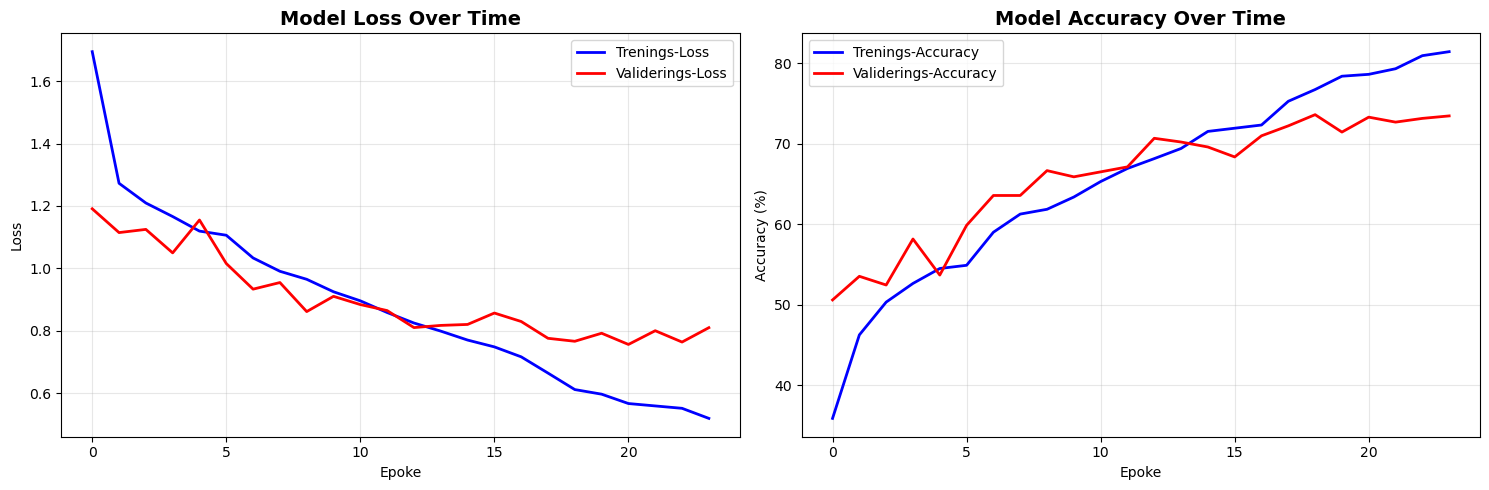

In [15]:
def plot_training_history(history):
    """Plot treningshistorikk"""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    
    # Loss plot
    axes[0].plot(history['train_losses'], label='Trenings-Loss', color='blue', linewidth=2)
    axes[0].plot(history['val_losses'], label='Validerings-Loss', color='red', linewidth=2)
    axes[0].set_title('Model Loss Over Time', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoke')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy plot
    axes[1].plot(history['train_accs'], label='Trenings-Accuracy', color='blue', linewidth=2)
    axes[1].plot(history['val_accs'], label='Validerings-Accuracy', color='red', linewidth=2)
    axes[1].set_title('Model Accuracy Over Time', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoke')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Plot treningshistorikk
print(" Visualiserer treningsresultater...")
plot_training_history(history)

> ### Stopp og tenk: treningskurvene
>
> Før du går videre, bruk et øyeblikk på å lese plottet aktivt:
> - Går `train_loss` og `val_loss` ned på en fornuftig måte?
> - Følger `train_accuracy` og `val_accuracy` hverandre, eller ser du et tydelig gap?
> - Virker early stopping og læringsrate-scheduler å ha oppført seg fornuftig?
>
> **Ikke gå videre før:**
> - du kan si om modellen virker å være underfittet, rimelig trent eller overfittet

 Viser sammendrag av treningsresultater...


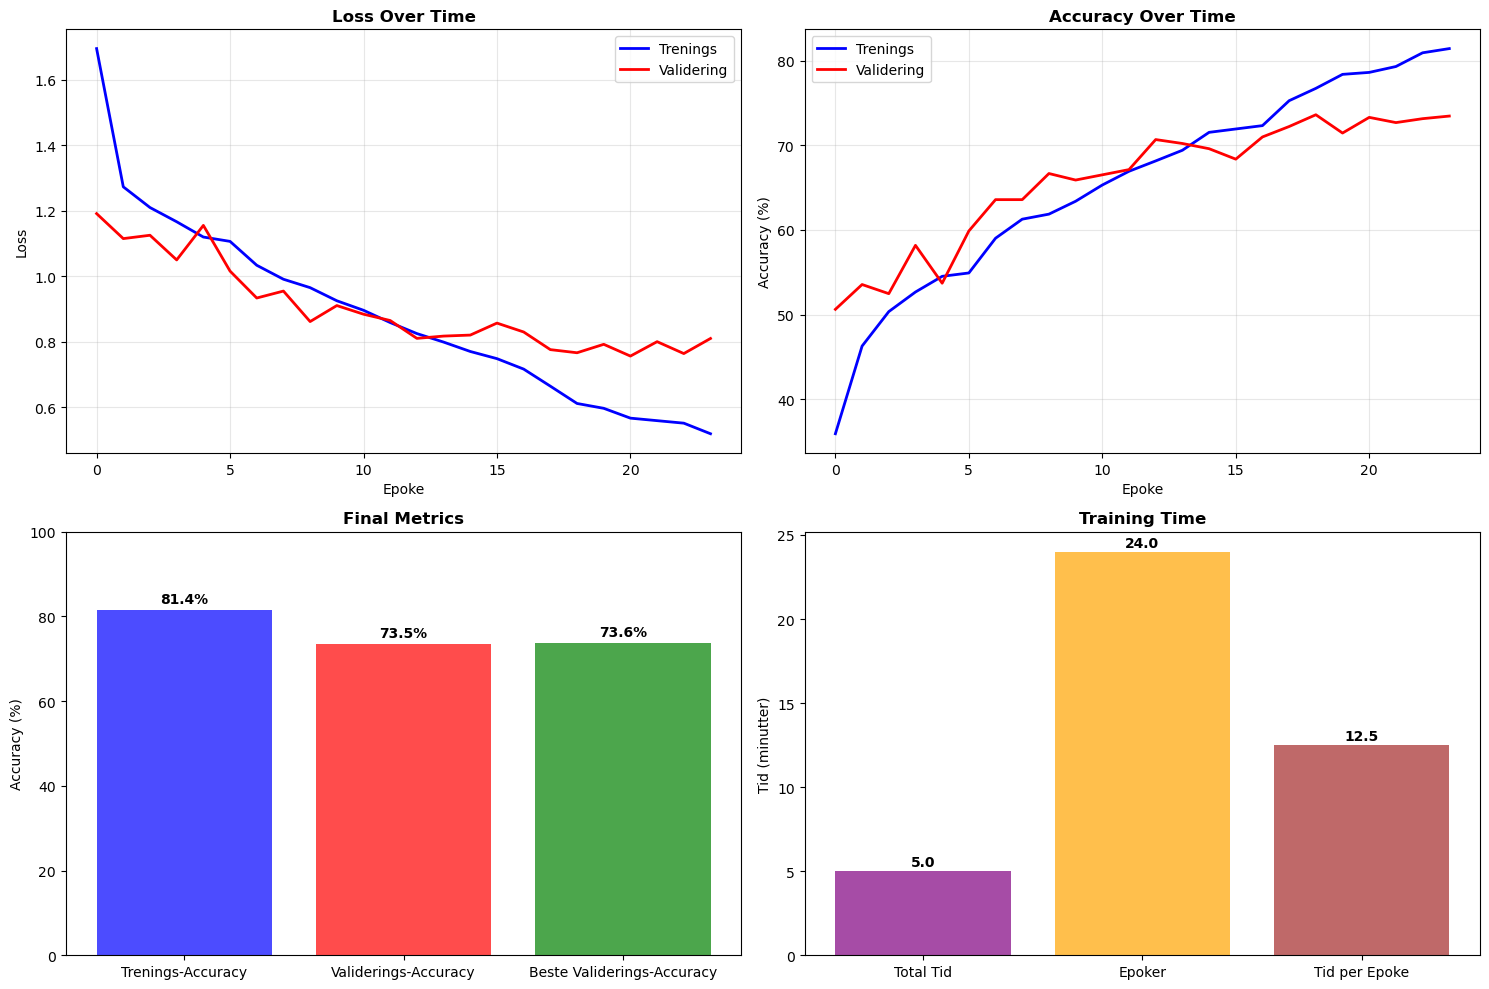

In [16]:
def plot_training_summary(history):
    """Plot sammendrag av treningsresultater"""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # 1. Loss over time
    axes[0, 0].plot(history['train_losses'], label='Trenings', color='blue', linewidth=2)
    axes[0, 0].plot(history['val_losses'], label='Validering', color='red', linewidth=2)
    axes[0, 0].set_title('Loss Over Time', fontweight='bold')
    axes[0, 0].set_xlabel('Epoke')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Accuracy over time
    axes[0, 1].plot(history['train_accs'], label='Trenings', color='blue', linewidth=2)
    axes[0, 1].plot(history['val_accs'], label='Validering', color='red', linewidth=2)
    axes[0, 1].set_title('Accuracy Over Time', fontweight='bold')
    axes[0, 1].set_xlabel('Epoke')
    axes[0, 1].set_ylabel('Accuracy (%)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # 3. Final metrics
    final_metrics = {
        'Trenings-Accuracy': history['train_accs'][-1],
        'Validerings-Accuracy': history['val_accs'][-1],
        'Beste Validerings-Accuracy': history['best_val_acc']
    }
    
    bars = axes[1, 0].bar(final_metrics.keys(), final_metrics.values(), 
                         color=['blue', 'red', 'green'], alpha=0.7)
    axes[1, 0].set_title('Final Metrics', fontweight='bold')
    axes[1, 0].set_ylabel('Accuracy (%)')
    axes[1, 0].set_ylim(0, 100)
    
    # Legg til verdier på balkene
    for bar, value in zip(bars, final_metrics.values()):
        axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                       f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # 4. Training time
    time_info = {
        'Total Tid': history['total_time']/60,
        'Epoker': len(history['train_accs']),
        'Tid per Epoke': history['total_time']/len(history['train_accs'])
    }
    
    bars = axes[1, 1].bar(time_info.keys(), time_info.values(), 
                         color=['purple', 'orange', 'brown'], alpha=0.7)
    axes[1, 1].set_title('Training Time', fontweight='bold')
    axes[1, 1].set_ylabel('Tid (minutter)')
    
    # Legg til verdier på balkene
    for bar, value in zip(bars, time_info.values()):
        axes[1, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                       f'{value:.1f}', ha='center', va='bottom', fontweight='bold')
    
    plt.tight_layout()
    plt.show()

# Plot sammendrag
print(" Viser sammendrag av treningsresultater...")
plot_training_summary(history)

### Mini-guide før analyse av treningsresultater

**Nå gjør du dette:**
- Kjør analysen etter at du har sett treningskurvene.
- Sammenlign tekstlig analyse med det du selv så i figurene.

**Nå se etter dette:**
- Om analysen stemmer med kurvene
- Hva som ser ut som styrker ved modellen
- Hvilke svakheter eller begrensninger som fortsatt er synlige

**Ikke gå videre før:**
- du selv har en mening om hvor godt modellen generaliserer

## 🔍 Analyse av treningsresultater

La oss analysere treningsresultatene for å forstå hvordan modellen lærte.

> ### Stopp og tenk: tolk treningsresultatene
>
> Før du går videre, prøv å svare kort på dette:
> - Ser modellen ut til å lære stabilt, eller er utviklingen ujevn?
> - Er gapet mellom trening og validering lite nok til at modellen virker å generalisere rimelig godt?
> - Hvis forbedringen stopper opp tidlig: hva kan det si om læringsrate, modellkapasitet eller datasettets vanskelighetsgrad?
>
> **Ikke gå videre før:**
> - du kan beskrive med 1-2 setninger hva som kjennetegner treningsforløpet
> - du har tatt stilling til om overfitting virker å være et problem

In [17]:
def analyze_training_results(history):
    """Analyser treningsresultater"""
    
    print("📊 Analyse av treningsresultater:")
    print("=" * 50)
    
    # Grunnleggende statistikk
    final_train_acc = history['train_accs'][-1]
    final_val_acc = history['val_accs'][-1]
    best_val_acc = history['best_val_acc']
    
    print(f"📊 Final trenings-accuracy: {final_train_acc:.2f}%")
    print(f"📊 Final validerings-accuracy: {final_val_acc:.2f}%")
    print(f"📊 Beste validerings-accuracy: {best_val_acc:.2f}%")
    
    # Overfitting-analyse
    overfitting_gap = final_train_acc - final_val_acc
    print(f"\n🔍 Overfitting-analyse:")
    print(f"  Gap mellom trenings- og validerings-accuracy: {overfitting_gap:.2f}%")
    
    if overfitting_gap > 10:
        print("  ⚠️ Modellen viser tegn til overfitting (gap > 10%)")
    elif overfitting_gap > 5:
        print("  ⚠️ Modellen viser moderate tegn til overfitting (gap > 5%)")
    else:
        print("  ✅ Modellen generaliserer godt (liten gap)")
    
    # Konvergens-analyse
    print(f"\n📈 Konvergens-analyse:")
    print(f"  Antall epoker: {len(history['train_accs'])}")
    print(f"  Total treningstid: {history['total_time']/60:.1f} minutter")
    print(f"  Gjennomsnittlig tid per epoke: {history['total_time']/len(history['train_accs']):.1f} sekunder")
    
    # Ytelse-vurdering
    print(f"\n🔍 Ytelse-vurdering:")
    if best_val_acc >= 90:
        print("  Utmerket ytelse! (≥90%)")
    elif best_val_acc >= 80:
        print("  God ytelse! (≥80%)")
    elif best_val_acc >= 70:
        print("  👍 Akseptabel ytelse (≥70%)")
    else:
        print("  ⚠️ Modellen trenger forbedring (<70%)")
    
    # Anbefalinger
    print(f"\n💡 Anbefalinger:")
    if overfitting_gap > 10:
        print("  - Øk dropout-raten")
        print("  - Legg til mer dataaugmentering")
        print("  - Reduser modellkompleksiteten")
    
    if best_val_acc < 80:
        print("  - Tren i flere epoker")
        print("  - Prøv forskjellige learning rates")
        print("  - Vurder å endre modellarkitekturen")
    
    if best_val_acc >= 80:
        print("  - Modellen er klar for evaluering!")
        print("  - Gå videre til del 3 for testing")

# Analyser resultater
analyze_training_results(history)

📊 Analyse av treningsresultater:
📊 Final trenings-accuracy: 81.43%
📊 Final validerings-accuracy: 73.46%
📊 Beste validerings-accuracy: 73.61%

🔍 Overfitting-analyse:
  Gap mellom trenings- og validerings-accuracy: 7.97%
  ⚠️ Modellen viser moderate tegn til overfitting (gap > 5%)

📈 Konvergens-analyse:
  Antall epoker: 24
  Total treningstid: 5.0 minutter
  Gjennomsnittlig tid per epoke: 12.5 sekunder

🔍 Ytelse-vurdering:
  👍 Akseptabel ytelse (≥70%)

💡 Anbefalinger:
  - Tren i flere epoker
  - Prøv forskjellige learning rates
  - Vurder å endre modellarkitekturen


## 💾 Lagring av trent modell

Vi lagrer den trente modellen og treningshistorikken for bruk i del 3.

### Mini-guide før lagring av trent modell

**Nå gjør du dette:**
- Kjør cellen som laster inn og lagrer beste modellvariant.
- Bekreft at modellfilene faktisk finnes etterpå.

**Nå se etter dette:**
- At den beste modellen ble valgt ut fra valideringsytelse
- Hvilke filer som lagres for videre bruk
- At du skjønner hvorfor vi skiller mellom arkitektur og trente vekter

**Ikke gå videre før:**
- du vet hvilken modellfil som skal brukes videre i neste notebook

In [18]:
# Last inn beste modell
model.load_state_dict(torch.load('best_flower_model.pth'))
print("✅ Beste modell lastet inn!")

# Lagre komplett modell
torch.save({
    'model_state_dict': model.state_dict(),
    'model_architecture': 'SimpleCNN',
    'num_classes': num_classes,
    'class_names': class_names,
    'class_mapping': class_mapping,
    'training_history': history
}, 'trained_flower_model.pth')

# Lagre treningshistorikk separat
with open('training_history.pkl', 'wb') as f:
    pickle.dump(history, f)

print("✅ Modell og historikk lagret!")
print(" Filer opprettet:")
print("  - best_flower_model.pth (beste modell)")
print("  - trained_flower_model.pth (komplett modell)")
print("  - training_history.pkl (treningshistorikk)")

✅ Beste modell lastet inn!
✅ Modell og historikk lagret!
 Filer opprettet:
  - best_flower_model.pth (beste modell)
  - trained_flower_model.pth (komplett modell)
  - training_history.pkl (treningshistorikk)


### Mini-guide før oppsummering og neste steg

**Nå gjør du dette:**
- Les oppsummeringen som kontroll på hva du faktisk har oppnådd i treningsdelen.
- Koble den til resultatene du nettopp så i kurver, analyse og lagrede filer.

**Nå se etter dette:**
- Hva som er trent ferdig i denne notebooken
- Hva som er lagret for videre bruk
- Hva som naturlig hører hjemme i neste del av CNN-løpet

**Ikke gå videre før:**
- du kan forklare forskjellen på modellarkitektur, trening og endelig testing

## Oppsummering og neste steg

### Hva vi har oppnådd:
- ✅ Lastet inn modell og data fra del 1
- ✅ Trente CNN-modellen med progress tracking
- ✅ Visualisert treningsresultater
- ✅ Analysert modellens ytelse
- ✅ Lagret trent modell og historikk

### Neste steg (del 3):
- 🧪 Testing av modellen på testsettet
- 🔍 Forvirringsmatrise og metrikker
- 🔍 Forklarbar AI (CAM, Grad-CAM)
- 🔍 Detaljert evaluering

### Refleksjonsspørsmål:
1. **Hvorfor** bruker vi early stopping i treningen?
2. **Hva** forteller treningskurvene oss om modellens læring?
3. **Hvordan** kan vi identifisere overfitting?
4. **Hvorfor** er det viktig å lagre både modell og historikk?

---

**Gå videre til del 3: `02c_cnn_testing.ipynb`**